In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

In [12]:
corpus = """
Deep learning is a subset of machine learning that uses neural networks with many layers to learn representations of data.
Neural networks are inspired by the structure of the human brain and consist of interconnected nodes called neurons.
Recurrent neural networks are designed to work with sequential data by maintaining a hidden state across time steps.
Language models learn the statistical structure of text and can generate new sequences that resemble the training corpus.
The LSTM architecture solves the vanishing gradient problem by introducing gates that control information flow.
GRU is a simplified version of LSTM that uses fewer parameters while achieving comparable performance on many tasks.
Training deep learning models requires large amounts of data and significant computational resources.
Gradient descent is the optimization algorithm used to minimize the loss function during neural network training.
Overfitting occurs when a model learns the training data too well and fails to generalize to new examples.
Regularization techniques such as dropout help prevent overfitting by randomly disabling neurons during training.
Word embeddings map words to dense vector representations that capture semantic relationships between words.
The attention mechanism allows models to focus on relevant parts of the input when making predictions.
Transfer learning enables models trained on large datasets to be fine-tuned for specific downstream tasks.
Natural language processing is a branch of AI focused on enabling computers to understand and generate human language.
Text generation models can produce coherent paragraphs by predicting the most likely next word given a context window.
"""

In [13]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1

input_sequences = []
for line in corpus.strip().split('\n'):
    line = line.strip()
    if not line:
        continue
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram = token_list[:i+1]
        input_sequences.append(n_gram)

max_seq_len = max(len(x) for x in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre')

X = input_sequences[:, :-1]
y = tf.keras.utils.to_categorical(input_sequences[:, -1], num_classes=total_words)

print(f"Vocabulary size: {total_words}")
print(f"Total sequences: {len(X)}")
print(f"Max sequence length: {max_seq_len}")

Vocabulary size: 157
Total sequences: 235
Max sequence length: 20


In [14]:
def build_model(model_type, vocab_size, seq_len, embed_dim=128, units=128):
    model = Sequential()
    model.add(Embedding(vocab_size, embed_dim, input_length=seq_len))

    if model_type == 'rnn':
        model.add(SimpleRNN(units))
    elif model_type == 'lstm':
        model.add(LSTM(units))
    elif model_type == 'gru':
        model.add(GRU(units))

    model.add(Dense(vocab_size, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

rnn_model  = build_model('rnn',  total_words, max_seq_len - 1)
lstm_model = build_model('lstm', total_words, max_seq_len - 1)
gru_model  = build_model('gru',  total_words, max_seq_len - 1)

rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
EPOCHS = 200

print("Training Vanilla RNN...")
rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=0)

print("Training LSTM...")
lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)

print("Training GRU...")
gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=0)

print("All models trained.")

Training Vanilla RNN...
Training LSTM...
Training GRU...
All models trained.


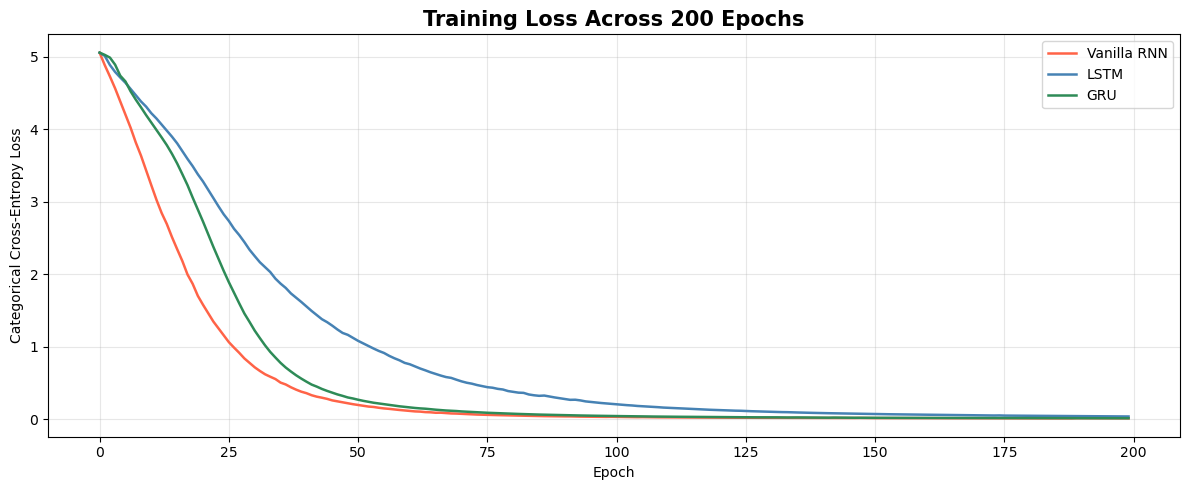

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(rnn_history.history['loss'],  label='Vanilla RNN',  color='tomato',    linewidth=1.8)
plt.plot(lstm_history.history['loss'], label='LSTM',         color='steelblue', linewidth=1.8)
plt.plot(gru_history.history['loss'],  label='GRU',          color='seagreen',  linewidth=1.8)

plt.title('Training Loss Across 200 Epochs', fontsize=15, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
def generate_text(model, tokenizer, seed_text, num_words=10, max_seq_len=max_seq_len):
    result = seed_text
    for _ in range(num_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len - 1, padding='pre')
        probs = model.predict(token_list, verbose=0)
        next_index = np.argmax(probs)
        next_word = tokenizer.index_word.get(next_index, '')
        result += ' ' + next_word
    return result

In [18]:
seed = "deep learning is"

rnn_output  = generate_text(rnn_model,  tokenizer, seed)
lstm_output = generate_text(lstm_model, tokenizer, seed)
gru_output  = generate_text(gru_model,  tokenizer, seed)

print(f"Seed phrase : '{seed}'\n")
print(f"Vanilla RNN : {rnn_output}")
print(f"LSTM        : {lstm_output}")
print(f"GRU         : {gru_output}")

Seed phrase : 'deep learning is'

Vanilla RNN : deep learning is a subset of machine learning that uses neural networks with
LSTM        : deep learning is a subset of machine learning that uses neural networks with
GRU         : deep learning is a subset of machine learning that uses neural networks with
